In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install datasets
!pip install -U accelerate
!pip install -U transformers
!pip install scikit-learn pillow torchvision opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manyli

In [4]:
from datasets import load_dataset

# replace 'cifar10' with the name of your dataset
dataset = load_dataset("cifar10")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [5]:
from sklearn.model_selection import train_test_split
from datasets import load_dataset, DatasetDict, load_metric


In [10]:
#!unzip "/content/drive/MyDrive/transformer/data2_OP.zip" -d "/content/drive/MyDrive/transformer"

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame150.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame180.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame210.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame240.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame270.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame30.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame300.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame330.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame360.jpg  
  inflating: /content/drive/MyDrive/transformer/data2_OP/1.no_cheating/90frame450.jpg  
  inflating: /content/drive/MyDrive/transfo

In [11]:
root_dir = '/content/drive/MyDrive/transformer/data2_OP'  # enter the path where your 'custom_dataset' folder is stored

In [12]:
ds = load_dataset("imagefolder", data_dir=root_dir)

Resolving data files:   0%|          | 0/9609 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [13]:
ds = ds['train'].train_test_split(test_size=0.3, stratify_by_column="label")  # 70% train, 30% test
ds_test = ds['test'].train_test_split(test_size=0.3, stratify_by_column="label")  # 30% test --> 15% valid, 15% test
ds = DatasetDict({
    'train': ds['train'],
    'test': ds_test['test'],
    'valid': ds_test['train']
})

del ds_test

In [14]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 6726
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 865
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 2018
    })
})

In [15]:
labels = ds['train'].features['label']
labels

ClassLabel(names=['1.no_cheating', '2.cheating'], id=None)

In [16]:
from PIL import Image
import torchvision.transforms as transforms

def transform(example_batch):
    # Define the desired image size
    desired_size = (224, 224)

    # Resize the images to the desired size
    resized_images = [transforms.Resize(desired_size)(x.convert("RGB")) for x in example_batch['image']]

    # Convert resized images to pixel values
    inputs = processor(resized_images, return_tensors='pt')

    # Don't forget to include the labels!
    inputs['label'] = example_batch['label']

    return inputs

prepared_ds = ds.with_transform(transform)

In [17]:
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['label'] for x in batch])
    }

metric = load_metric("accuracy")

def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

<ipython-input-17-39936b66210a>:7: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  metric = load_metric("accuracy")


The repository for accuracy contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/accuracy.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


In [18]:
from transformers import AutoImageProcessor, ViTForImageClassification

model_name_or_path = 'google/vit-base-patch16-224-in21k'
labels=['1.no_cheating', '2.cheating']
processor = AutoImageProcessor.from_pretrained(model_name_or_path)
model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=2,
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)},
    ignore_mismatched_sizes=True
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
from transformers import TrainingArguments

root_dir = "/ViT_custom/"  # Path where all config files and checkpoints will be saved
training_args = TrainingArguments(
  output_dir=root_dir,
  per_device_train_batch_size=16,
  evaluation_strategy="epoch",
  save_strategy="epoch",
  fp16=True,
  num_train_epochs=60,
  logging_steps=500,
  learning_rate=2e-4,
  save_total_limit=1,
  remove_unused_columns=False,
  push_to_hub=False,
  report_to='tensorboard',
  load_best_model_at_end=True,
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [20]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["valid"],
    tokenizer=processor,
)

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

save_dir = '/content/drive/MyDrive/siham/to/ViT_custom/best_model/'  # Define the path to save the model
train_results = trainer.train()
trainer.save_model(save_dir)  # Save the best model
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()




Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.223544,0.918236
2,0.279000,0.190862,0.933102
3,0.176400,0.169980,0.940535
4,0.128400,0.179173,0.942517
5,0.111700,0.155663,0.944500
6,0.090800,0.165618,0.946977
7,0.090800,0.211810,0.938057
8,0.064800,0.223584,0.944995
9,0.056600,0.201275,0.950446
10,0.049200,0.215177,0.937562


***** train metrics *****
  epoch                    =          60.0
  total_flos               = 29124941051GF
  train_loss               =        0.0298
  train_runtime            =    1:53:51.71
  train_samples_per_second =        59.072
  train_steps_per_second   =         3.697


In [22]:
metrics = trainer.evaluate(prepared_ds['test'])
trainer.log_metrics("test", metrics)
trainer.save_metrics("test", metrics)

***** test metrics *****
  epoch                   =       60.0
  eval_accuracy           =     0.9341
  eval_loss               =     0.1747
  eval_runtime            = 0:00:09.04
  eval_samples_per_second =     95.677
  eval_steps_per_second   =     12.056


Recall for 1.no_cheating: 0.92
Recall for 2.cheating: 0.95


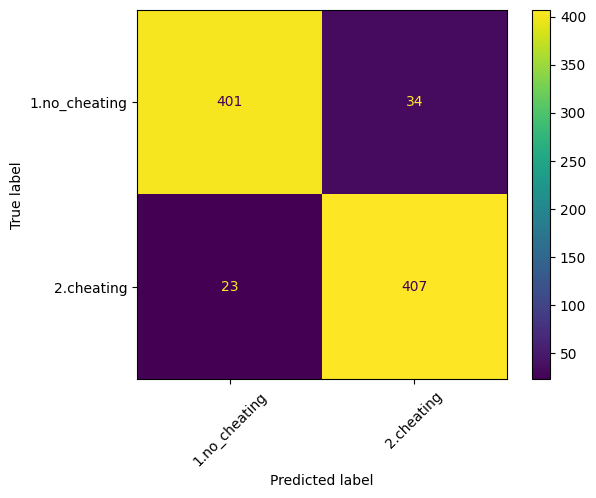

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score

test_ds = ds['test'].with_transform(transform)
test_outputs = trainer.predict(test_ds)

y_true = test_outputs.label_ids
y_pred = test_outputs.predictions.argmax(1)

labels = test_ds.features["label"].names
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)

recall = recall_score(y_true, y_pred, average=None)

# Print the recall for each class
for label, score in zip(labels, recall):
  print(f"Recall for {label}: {score:.2f}")

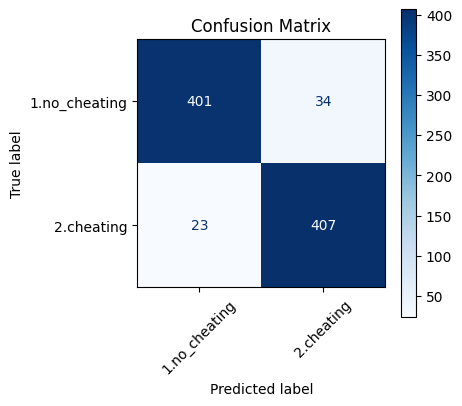

1.no_cheating: Recall = 0.92, Precision = 0.95, F1 Score = 0.93
2.cheating: Recall = 0.95, Precision = 0.92, F1 Score = 0.93


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

test_ds = ds['test'].with_transform(transform)
test_outputs = trainer.predict(test_ds)

y_true = test_outputs.label_ids
y_pred = test_outputs.predictions.argmax(1)

labels = test_ds.features["label"].names
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Plot confusion matrix with enhanced appearance
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(xticks_rotation=45, ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Calculate recall, precision, and F1 score
recall = recall_score(y_true, y_pred, average=None)
precision = precision_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Print recall, precision, and F1 score for each class
for label, r, p, f in zip(labels, recall, precision, f1):
    print(f"{label}: Recall = {r:.2f}, Precision = {p:.2f}, F1 Score = {f:.2f}")


In [25]:
def getPrediction(image):
    model_name_or_path = 'google/vit-base-patch16-224-in21k'
    processor = AutoImageProcessor.from_pretrained(model_name_or_path)
    vit = ViTForImageClassification.from_pretrained(save_dir)
    model = pipeline('image-classification', model=vit, feature_extractor=processor)

    result = model(image)
    return result

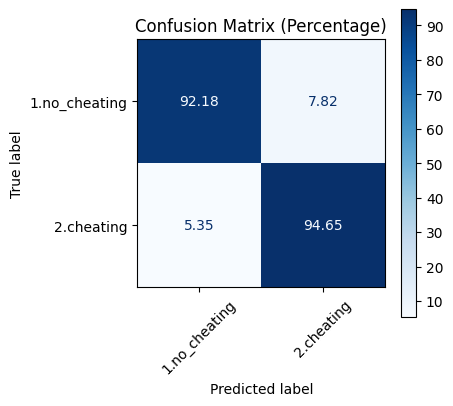

1.no_cheating: Recall = 0.92, Precision = 0.95, F1 Score = 0.93
2.cheating: Recall = 0.95, Precision = 0.92, F1 Score = 0.93


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming `test_ds` and `trainer.predict` are already defined as in your code
test_ds = ds['test'].with_transform(transform)
test_outputs = trainer.predict(test_ds)

y_true = test_outputs.label_ids
y_pred = test_outputs.predictions.argmax(1)

labels = test_ds.features["label"].names
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix to percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)

# Plot confusion matrix with enhanced appearance
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(xticks_rotation=45, ax=ax, cmap='Blues', values_format='.2f')
plt.title('Confusion Matrix (Percentage)')
plt.show()

# Calculate recall, precision, and F1 score
recall = recall_score(y_true, y_pred, average=None)
precision = precision_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Print recall, precision, and F1 score for each class
for label, r, p, f in zip(labels, recall, precision, f1):
    print(f"{label}: Recall = {r:.2f}, Precision = {p:.2f}, F1 Score = {f:.2f}")


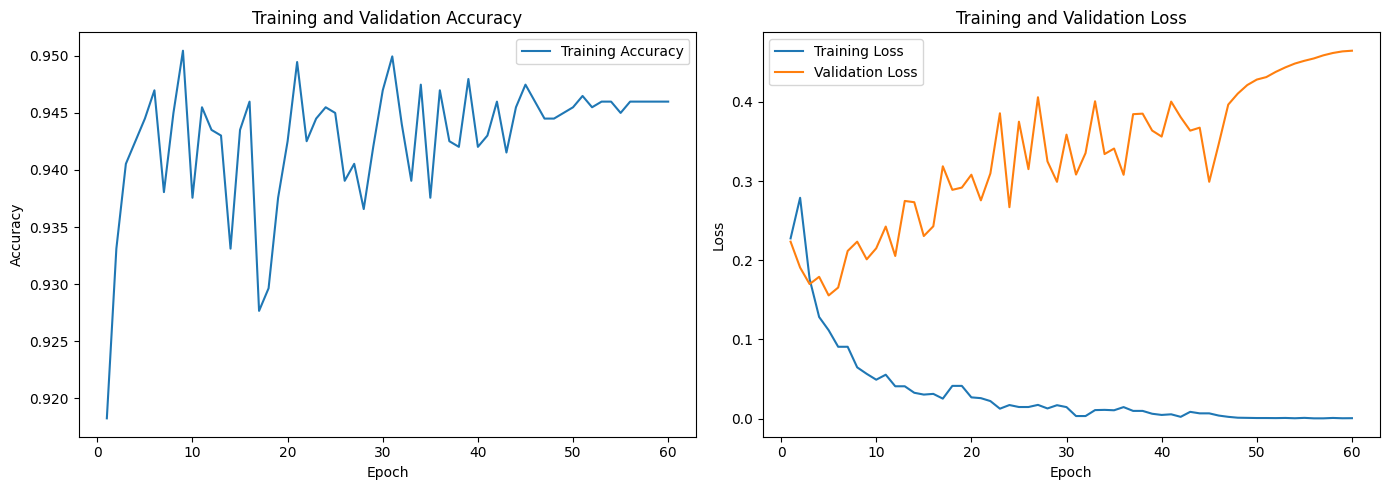

In [43]:
import matplotlib.pyplot as plt

# Provided data
epochs = list(range(1, 61))
training_loss = [
    None, 0.279000, 0.176400, 0.128400, 0.111700, 0.090800, 0.090800, 0.064800, 0.056600, 0.049200,
    0.055500, 0.040900, 0.040900, 0.032700, 0.030400, 0.031300, 0.025300, 0.041400, 0.041400, 0.026900,
    0.025900, 0.022200, 0.012600, 0.017200, 0.014700, 0.014700, 0.017400, 0.012900, 0.017000, 0.014600,
    0.003300, 0.003300, 0.010800, 0.011100, 0.010600, 0.014600, 0.009800, 0.009800, 0.006200, 0.004700,
    0.005500, 0.002300, 0.008600, 0.006700, 0.006700, 0.003900, 0.002300, 0.001200, 0.001000, 0.000800,
    0.000800, 0.000700, 0.000900, 0.000500, 0.001000, 0.000400, 0.000400, 0.000900, 0.000500, 0.000600
]
validation_loss = [
    0.223544, 0.190862, 0.169980, 0.179173, 0.155663, 0.165618, 0.211810, 0.223584, 0.201275, 0.215177,
    0.242648, 0.205482, 0.274986, 0.273404, 0.230676, 0.242993, 0.318772, 0.289032, 0.291895, 0.308130,
    0.275746, 0.309804, 0.385721, 0.267098, 0.375090, 0.315177, 0.405971, 0.324964, 0.299139, 0.358779,
    0.308350, 0.335437, 0.400943, 0.334213, 0.341205, 0.308042, 0.384596, 0.385266, 0.363916, 0.356312,
    0.400481, 0.380796, 0.363804, 0.367570, 0.299175, 0.346982, 0.396706, 0.410575, 0.421384, 0.428308,
    0.431439, 0.438078, 0.443708, 0.448537, 0.452033, 0.455014, 0.458946, 0.461898, 0.463912, 0.464764
]
accuracy = [
    0.918236, 0.933102, 0.940535, 0.942517, 0.944500, 0.946977, 0.938057, 0.944995, 0.950446, 0.937562,
    0.945491, 0.943508, 0.943013, 0.933102, 0.943508, 0.945986, 0.927651, 0.929633, 0.937562, 0.942517,
    0.949455, 0.942517, 0.944500, 0.945491, 0.944995, 0.939049, 0.940535, 0.936571, 0.942022, 0.946977,
    0.949950, 0.944004, 0.939049, 0.947473, 0.937562, 0.946977, 0.942517, 0.942022, 0.947968, 0.942022,
    0.943013, 0.945986, 0.941526, 0.945491, 0.947473, 0.945986, 0.944500, 0.944500, 0.944995, 0.945491,
    0.946482, 0.945491, 0.945986, 0.945986, 0.944995, 0.945986, 0.945986, 0.945986, 0.945986, 0.945986
]

# Replace 'None' with the average of the first two available values
training_loss[0] = sum(training_loss[1:3])/2

# Plotting the graphs
plt.figure(figsize=(14, 5))

# Training and Validation Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label='Training Accuracy')
#plt.plot(epochs, accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Training and Validation Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [33]:
print(train_results.metrics.keys())


dict_keys(['train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss', 'epoch'])


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


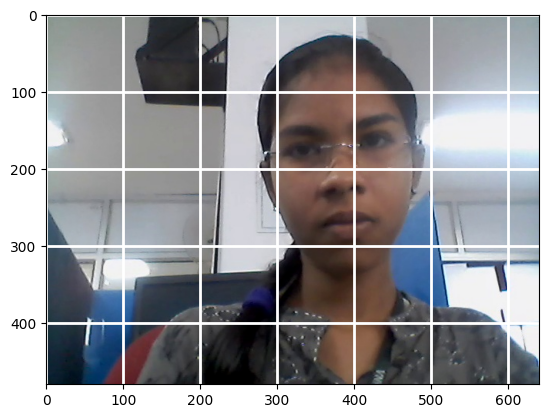

In [50]:
import torch
from transformers import AutoImageProcessor, ViTForImageClassification
from PIL import Image
import matplotlib.pyplot as plt

# Load image
image_path = "/content/drive/MyDrive/transformer/data2_OP/1.no_cheating/193frame285.jpg"
image = Image.open(image_path)

# Define model and processor
model_name_or_path = 'google/vit-base-patch16-224-in21k'
labels = ['1.no_cheating', '2.cheating']

processor = AutoImageProcessor.from_pretrained(model_name_or_path)
model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=2,
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)},
    ignore_mismatched_sizes=True
)

# Preprocess the image
inputs = processor(images=image, return_tensors="pt")

# Forward pass through the model (inference)
with torch.no_grad():
    outputs = model(**inputs)

# Visualize the image with a grid overlay
plt.imshow(image)
plt.grid(True, which='both', color='white', linewidth=2)
plt.show()



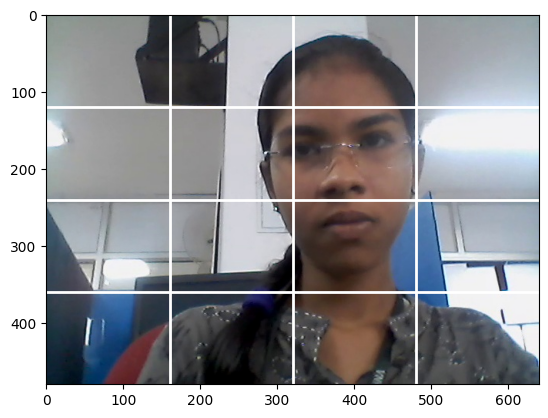

In [52]:
# Preprocess the image
inputs = processor(images=image, return_tensors="pt")

# Forward pass through the model (inference)
with torch.no_grad():
    outputs = model(**inputs)

# Convert image to numpy array for easy manipulation
image_np = np.array(image)

# Get image dimensions
height, width, _ = image_np.shape

# Define the number of patches (4x4 for 16 patches)
num_patches = 4
patch_height = height // num_patches
patch_width = width // num_patches

# Draw the grid on the image by dividing into 16 patches
fig, ax = plt.subplots()
ax.imshow(image_np)

# Draw horizontal lines
for i in range(1, num_patches):
    ax.axhline(i * patch_height, color='white', linewidth=2)

# Draw vertical lines
for i in range(1, num_patches):
    ax.axvline(i * patch_width, color='white', linewidth=2)

plt.show()

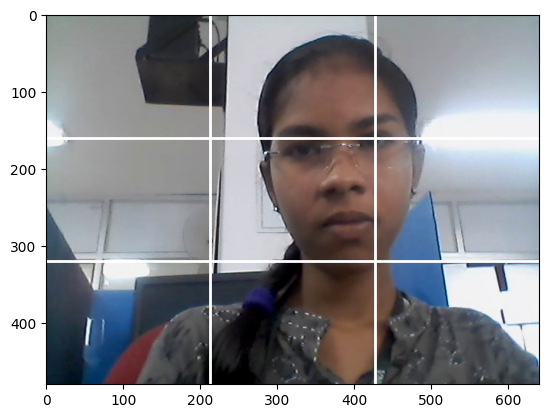

In [53]:
# Preprocess the image
inputs = processor(images=image, return_tensors="pt")

# Forward pass through the model (inference)
with torch.no_grad():
    outputs = model(**inputs)

# Convert image to numpy array for easy manipulation
image_np = np.array(image)

# Get image dimensions
height, width, _ = image_np.shape

# Define the number of patches (4x4 for 16 patches)
num_patches = 3
patch_height = height // num_patches
patch_width = width // num_patches

# Draw the grid on the image by dividing into 16 patches
fig, ax = plt.subplots()
ax.imshow(image_np)

# Draw horizontal lines
for i in range(1, num_patches):
    ax.axhline(i * patch_height, color='white', linewidth=2)

# Draw vertical lines
for i in range(1, num_patches):
    ax.axvline(i * patch_width, color='white', linewidth=2)

plt.show()